# Proyecto Final

### **Predicción del Precio del Oro mediante Indicadores Macroeconómicos Globales**

|                |   |
:----------------|---|
| **Nombre**     |  Jorge Oviedo Magaña, Alan Almaraz|
| **Fecha**      | 05/05/2026 |
| **Expediente** |  757048 | 

## 1. Objetivos

### 1.1 Objetivo General

Analizar la relación entre el precio diario del oro (XAU/USD) y los principales indicadores macroeconómicos globales —índice del dólar (DXY), precio del petróleo crudo e inflación— mediante la implementación y comparación de modelos de ensamble (Random Forest y XGBoost), con el fin de determinar el modelo con mayor capacidad predictiva medido a través del RMSE obtenido por validación cruzada temporal.

### 1.2 Objetivos Específicos

1. Realizar un análisis exploratorio del dataset para comprender la evolución temporal del precio del oro, sus distribuciones y su correlación con los indicadores macroeconómicos seleccionados.
2. Aplicar ingeniería de características temporales (rezagos y medias móviles) para enriquecer el conjunto de predictores y evitar fuga de información (*data leakage*).
3. Describir el marco teórico de regresión lineal, árboles de decisión, métodos de ensamble y boosting como base conceptual de los modelos propuestos.
4. Implementar y optimizar un modelo **Random Forest** para regresión mediante búsqueda aleatoria de hiperparámetros (`RandomizedSearchCV`).
5. Implementar y optimizar un modelo **XGBoost** para regresión mediante búsqueda aleatoria de hiperparámetros (`RandomizedSearchCV`).
6. Comparar ambos modelos utilizando **validación cruzada temporal** (`TimeSeriesSplit`, $k=5$), reportando media y desviación estándar del RMSE.
7. Construir un pipeline reproducible que integre preprocesamiento y modelado, garantizando la correcta separación temporal entre entrenamiento y validación.

---

# Marco Teórico

## 2.1 Regresión Lineal

La regresión lineal es uno de los métodos más simples y fundamentales en aprendizaje estadístico. Busca modelar la relación entre una variable respuesta $Y$ y uno o más predictores $X_1, X_2, \ldots, X_p$ mediante la función:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon$$

donde $\beta_0$ es el intercepto, $\beta_1, \ldots, \beta_p$ son los coeficientes del modelo, y $\varepsilon$ es el término de error. Los coeficientes se estiman minimizando la **Suma de Cuadrados Residuales (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

---

### 2.1.1 Seis Problemas Potenciales en una Regresión (ISLP)

---

#### 1) Non-linearity of Data (No linealidad de los datos)

**Definición**

La relación entre las variables dependientes e independientes no se puede representar con una línea recta. El modelo lineal asume una relación lineal entre $Y$ y cada $X_j$; si la relación real es no lineal, el modelo tendrá un sesgo sistemático.

**Impacto**

Tienes tu modelo mal — las predicciones serán sistemáticamente incorrectas en ciertas regiones del espacio de predictores.

**¿Cómo identificar?**

El error te dice si el patrón es lineal o no. Se analiza la **gráfica de residuos vs. valores ajustados**: si se observa un patrón (curva, arco), la linealidad no se cumple.

**¿Cómo arreglarlo?**

Cambiando el modelo mediante transformaciones polinomiales o de interacción (`poly`, `int`), como incluir términos $X^2$ o $\log(X)$.

---

#### 2) Correlation of Error Terms (Correlación de los términos de error)

**Definición**

Los errores no deben tener ninguna correlación entre sí mismos. La regresión lineal asume que los errores $\varepsilon_i$ son independientes entre sí, es decir, $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0$ para $i \neq j$.

**Impacto**

Los errores se construyen sobre los errores anteriores. La autocorrelación subestima los errores estándar, dando falsa precisión a los coeficientes.

**¿Cómo identificar?**

El modelo tiene patrones en los residuos al graficarlos en función del tiempo o del orden de las observaciones.

**¿Cómo arreglarlo?**

Usar series de tiempo (modelos como ARIMA o incluir estructura temporal en los predictores).

---

#### 3) Non-constant Variance of Error Terms — Heteroscedasticity (Heterocedasticidad)

**Definición**

Las varianzas de los errores no son constantes. El supuesto de homocedasticidad requiere que $\text{Var}(\varepsilon_i) = \sigma^2$ sea constante para todas las observaciones.

**Impacto**

Inferencias y errores estándar incorrectos. Los estimadores siguen siendo insesgados pero los errores estándar son incorrectos, lo que invalida pruebas de hipótesis e intervalos de confianza.

**¿Cómo identificar?**

Los residuos tienen forma de embudo al graficarse contra los valores ajustados — la varianza crece o decrece con el nivel de la respuesta.

**¿Cómo arreglarlo?**

Usar ingeniería de características en $Y$ (transformarla), por ejemplo:

$$Y^* = \log(Y + c)$$

---

#### 4) Outliers (Valores atípicos)

**Definición**

Observaciones que se desvían de la tendencia esperada en $\hat{Y}$ en más de 3 desviaciones estándar (regla $\pm 3\sigma$). Son observaciones cuyo valor de $Y$ es inusualmente alto o bajo dado el valor de sus predictores.

**Impacto**

Pueden distorsionar análisis, correlaciones o modelos predictivos. Aunque un solo outlier puede no afectar drásticamente los coeficientes, sí puede inflar el RSE y alterar el $R^2$.

**¿Cómo identificar?**

Con los residuos, z-score o gráficos estadísticos (regla $3\sigma$). Se usan los **residuos estudentizados** — observaciones con $|e_i^*| > 3$ son candidatos a outliers.

**¿Cómo arreglarlo?**

Eliminando o transformando los datos problemáticos.

---

#### 5) High Leverage Points (Puntos de alto apalancamiento)

**Definición**

Son valores con sesgo extremo en la variable independiente $X$; es decir, están muy alejados del promedio y tienen mucho peso sobre la recta ajustada $\hat{Y} = \beta_0 + \beta_1 X$. A diferencia de los outliers (inusuales en $Y$), los puntos de alto apalancamiento son inusuales en el espacio de los predictores.

**Impacto**

Pueden cambiar significativamente la pendiente, afectando la regresión de forma desproporcionada.

**¿Cómo identificar?**

Se detectan con la **estadística de apalancamiento** $h_i$:

$$h_i = \frac{1}{n} \frac{(x_i - \bar{x})^2}{\sum_{j=1}^{n}(x_j - \bar{x})^2}$$

Es un punto de alto apalancamiento cuando:

$$h_i > \frac{p+1}{n}$$

**¿Cómo arreglarlo?**

Si afectan a la pendiente, lo mejor es eliminarlos.

---

#### 6) Collinearity (Colinealidad / Multicolinealidad)

**Definición**

Cuando dos o más variables independientes están altamente correlacionadas entre sí. Esto dificulta aislar el efecto individual de cada predictor sobre $Y$.

**Impacto**

Hace inestables a los coeficientes y dificulta su interpretación. Aumenta la varianza de los coeficientes estimados y puede hacer que coeficientes significativos parezcan no serlo.

**¿Cómo identificar?**

VIF alto. Se cuantifica con el **Factor de Inflación de la Varianza (VIF)**:

$$\text{VIF}(\hat{\beta}_j) = \frac{1}{1 - R^2_{X_j | X_{-j}}}$$

Un VIF mayor a 5 o 10 indica un nivel problemático de multicolinealidad.

**¿Cómo arreglarlo?**

Eliminar o combinar variables correlacionadas, o usar regresión regularizada (Ridge, Lasso).

## 2.2 Árbol para Regresión

Los árboles de decisión para regresión particionan el espacio de predictores en regiones rectangulares y asignan un valor constante a cada región. El proceso es **top-down** y **greedy**: en cada paso se selecciona el predictor $X_j$ y el punto de corte $s$ que minimizan el RSS:

$$\text{RSS} = \sum_{i: x_i \in R_1}(y_i - \hat{y}_{R_1})^2 + \sum_{i: x_i \in R_2}(y_i - \hat{y}_{R_2})^2$$

La predicción es el **promedio** de los valores en la región terminal. Se regularizan con **poda** (*pruning*) añadiendo un término $\alpha|T|$ al RSS, donde $|T|$ es el número de nodos terminales.


## 2.3 Árbol para Clasificación

En lugar del RSS, usa medidas de **impureza del nodo**:

- **Índice de Gini:** $G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$
- **Entropía:** $D = -\sum_{k=1}^{K} \hat{p}_{mk} \log \hat{p}_{mk}$

La predicción es la **clase mayoritaria** en el nodo terminal.

## 2.4 Bootstrap

Técnica de remuestreo que genera $B$ muestras **con reemplazo** del mismo tamaño $n$ para estimar la incertidumbre de un estadístico sin supuestos paramétricos. Permite calcular errores estándar e intervalos de confianza para cualquier estimador. Aproximadamente $1/3$ de las observaciones quedan fuera de cada muestra (*out-of-bag*, OOB), lo que permite estimar el error de prueba sin necesidad de un conjunto de validación separado.

$$\widehat{\text{SE}}_B(\hat{\alpha}) = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\hat{\alpha}^{*b} - \frac{1}{B}\sum_{b'=1}^{B}\hat{\alpha}^{*b'}\right)^2}$$


## 2.5 Ensambles de Modelos

Método que combina múltiples modelos base para producir una predicción más robusta y precisa que cualquier modelo individual. Para regresión se promedian las predicciones; para clasificación se usa votación mayoritaria:

$$\hat{f}_{\text{ensamble}}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(x)$$


## 2.6 Bagging (Bootstrap Aggregation)

Combina bootstrap y ensamble: entrena $B$ árboles sin podar sobre muestras bootstrap independientes y promedia sus predicciones. Su objetivo es reducir la **varianza** del modelo sin aumentar el sesgo. **Random Forest** extiende el bagging añadiendo aleatoriedad en la selección de predictores en cada corte ($m \approx \sqrt{p}$), decorrelacionando los árboles entre sí y reduciendo aún más la varianza del ensamble.


## 2.7 Boosting

Método de ensamble que entrena modelos de forma **secuencial**: cada modelo nuevo corrige los errores del anterior ajustándose sobre los residuos, reduciendo el **sesgo** progresivamente. La tasa de aprendizaje $\lambda$ controla la contribución de cada árbol al modelo final:

$$\hat{f}_b(x) = \hat{f}_{b-1}(x) + \lambda \hat{f}^b(x)$$

**XGBoost** es una implementación optimizada de gradient boosting que añade regularización L1/L2, manejo de valores faltantes y paralelización.

In [2]:
# ============================================================
# Importación de librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

## 4. Análisis Exploratorio de Datos (EDA)

El EDA tiene tres objetivos concretos en este proyecto:
1. Comprender la estructura y calidad del dataset.
2. Explorar la evolución temporal del precio del oro y su relación con los indicadores.
3. Fundamentar las decisiones de ingeniería de características que se aplicarán antes del modelado.

---

### 4.1 Carga e Inspección Inicial

In [3]:
df = pd.read_csv('Gold_vs_Economic_Factors_2015_2026.csv')

# Convertir Date a datetime para manejo correcto en gráficas y operaciones
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Gold_Price_XAU_USD,US_Dollar_Index_DXY,Crude_Oil_Price,Inflation_Rate_Pct
0,2015-01-01,1205.47,95.17,47.85,7.92
1,2015-01-02,1204.58,95.61,48.71,6.17
2,2015-01-03,1211.56,95.62,53.73,4.80
3,2015-01-04,1227.29,95.93,55.39,6.95
4,2015-01-05,1225.45,96.75,53.76,5.99


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4137 entries, 0 to 4136
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 4137 non-null   datetime64[ns]
 1   Gold_Price_XAU_USD   4137 non-null   float64       
 2   US_Dollar_Index_DXY  4137 non-null   float64       
 3   Crude_Oil_Price      4137 non-null   float64       
 4   Inflation_Rate_Pct   4137 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 161.7 KB


In [5]:
df.isnull().sum()

Date                   0
Gold_Price_XAU_USD     0
US_Dollar_Index_DXY    0
Crude_Oil_Price        0
Inflation_Rate_Pct     0
dtype: int64

In [6]:
df.describe().round(2)

,Date,Gold_Price_XAU_USD,US_Dollar_Index_DXY,Crude_Oil_Price,Inflation_Rate_Pct
count,4137,4137.00,4137.00,4137.00,4137.00
mean,2020-08-30 00:00:00,2825.36,55.31,274.74,5.07
min,2015-01-01 00:00:00,1106.38,27.05,47.85,1.50
25%,2017-10-31 00:00:00,2034.88,39.28,227.14,3.37
50%,2020-08-30 00:00:00,3047.79,53.11,282.70,5.09
75%,2023-06-30 00:00:00,3625.97,72.52,320.75,6.76
max,2026-04-29 00:00:00,4176.60,97.09,463.81,8.50
std,NaN,927.41,17.15,88.50,2.01


**Observaciones de la inspección inicial:**

- El dataset no presenta valores nulos, lo que confirma la descripción del autor.
- El precio del oro muestra una amplitud considerable entre su mínimo y máximo, lo que refleja la volatilidad del período 2015–2026.
- El DXY oscila en un rango moderado, coherente con los movimientos históricos del índice del dólar.
- La tasa de inflación tiene una distribución que conviene explorar visualmente para identificar si los valores interpolados generan artefactos en la distribución.

---

### 4.2 Evolución Temporal de las Variables

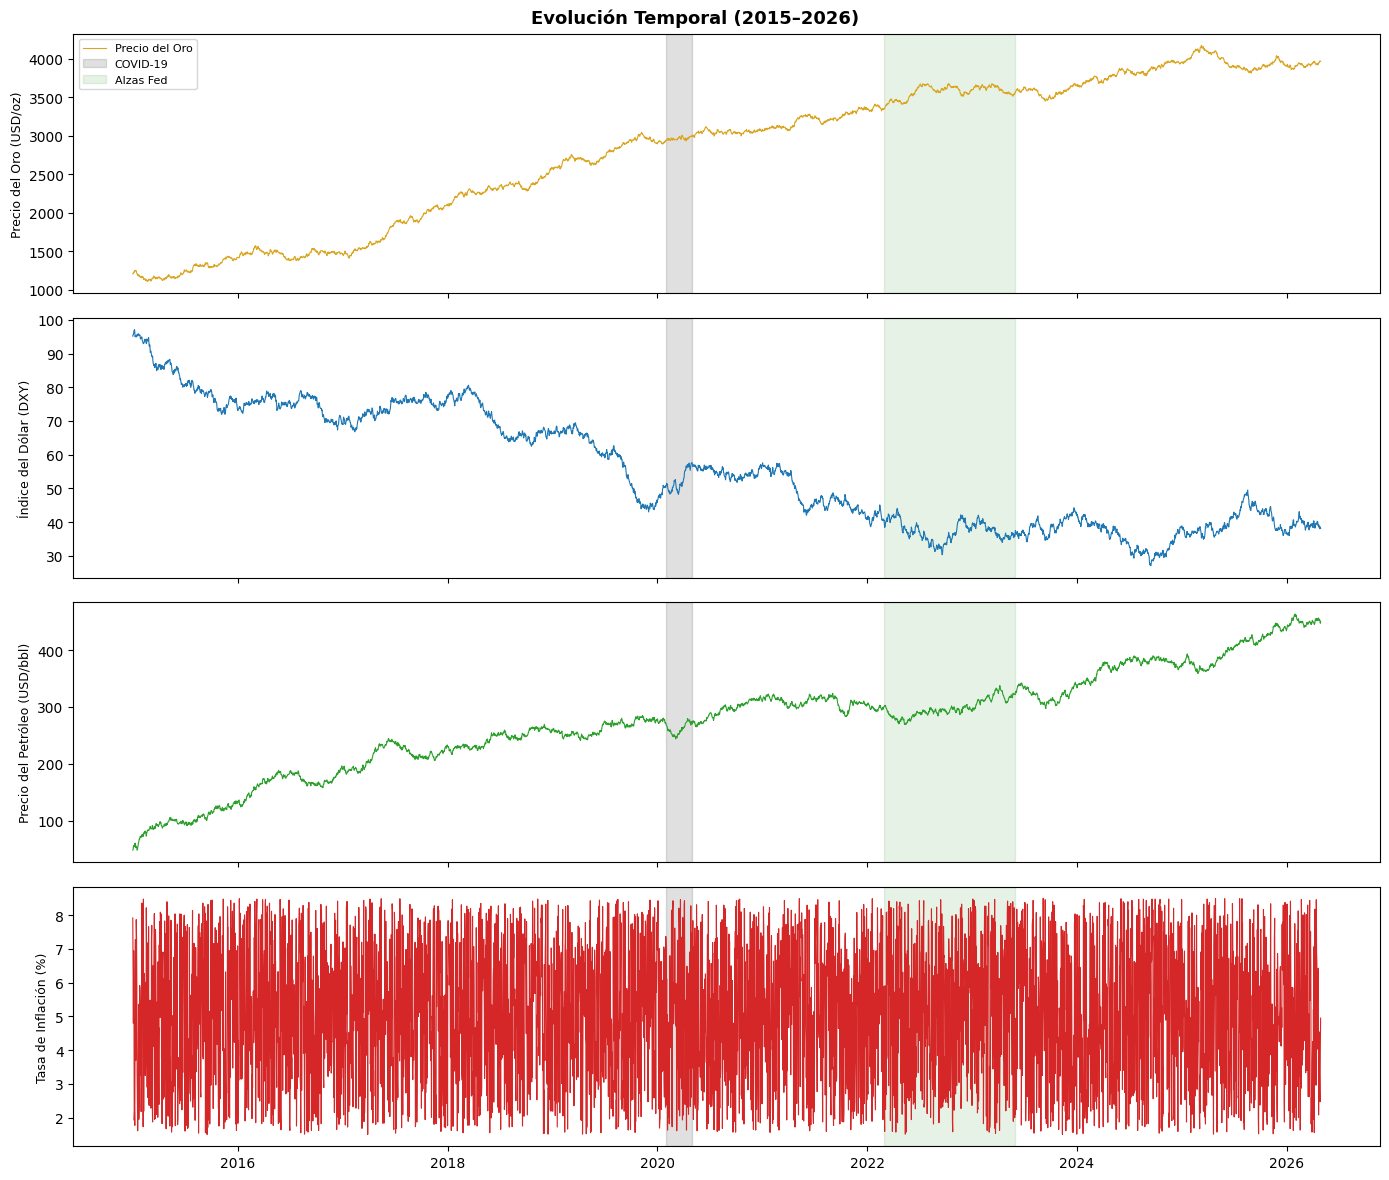

In [20]:
# Series temporales
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

variables = [
    ('Gold_Price_XAU_USD',  'Precio del Oro (USD/oz)',       '#DAA520'),
    ('US_Dollar_Index_DXY', 'Índice del Dólar (DXY)',        '#1F77B4'),
    ('Crude_Oil_Price',     'Precio del Petróleo (USD/bbl)', '#2CA02C'),
    ('Inflation_Rate_Pct',  'Tasa de Inflación (%)',         '#D62728'),
]

for ax, (col, label, color) in zip(axes, variables):
    ax.plot(df['Date'], df[col], color=color, linewidth=0.8)
    ax.set_ylabel(label, fontsize=9)
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'), alpha=0.12, color='black')
    ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2023-06-01'), alpha=0.10, color='green')

axes[0].legend(['Precio del Oro', 'COVID-19', 'Alzas Fed'], fontsize=8, loc='upper left')
fig.suptitle('Evolución Temporal (2015–2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis de la evolución temporal:**

- El precio del oro muestra una **tendencia alcista de largo plazo** con dos aceleraciones notables: durante la pandemia COVID-19 (2020) y a partir del ciclo geopolítico de 2022–2024.
- El DXY presenta movimientos **inversamente correlacionados** con el oro en varios subperíodos, consistente con la teoría económica.
- El petróleo tuvo una **caída extrema en 2020** (llegó a valores negativos en futuros WTI), lo que representa un evento atípico que los modelos deben procesar.
- La inflación muestra el perfil esperado: baja y estable pre-pandemia, pico pronunciado en 2021–2022, y descenso posterior.

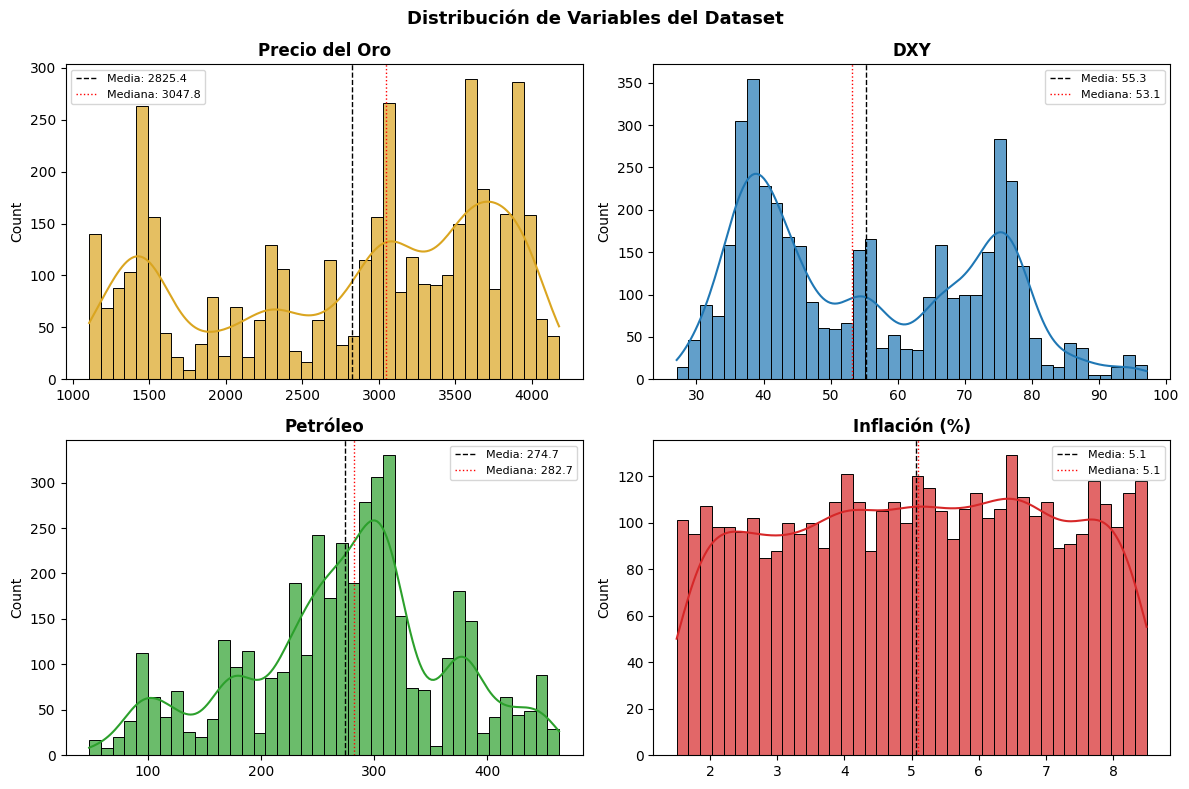

In [8]:
# ============================================================
# Histogramas y densidades
# ============================================================
cols_num = ['Gold_Price_XAU_USD', 'US_Dollar_Index_DXY', 'Crude_Oil_Price', 'Inflation_Rate_Pct']
labels   = ['Precio del Oro', 'DXY', 'Petróleo', 'Inflación (%)']
colors   = ['#DAA520', '#1F77B4', '#2CA02C', '#D62728']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col, label, color in zip(axes, cols_num, labels, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=40, alpha=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='red', linestyle=':', linewidth=1, label=f'Mediana: {df[col].median():.1f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribución de Variables del Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Correlación entre Variables

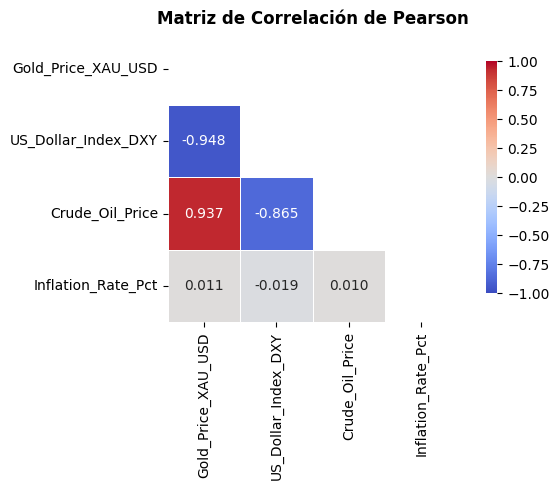


Correlaciones con Gold_Price_XAU_USD (ordenadas):
US_Dollar_Index_DXY   -0.947840
Crude_Oil_Price        0.936524
Inflation_Rate_Pct     0.010855
Name: Gold_Price_XAU_USD, dtype: float64


In [9]:
# ============================================================
# Matriz de correlación de Pearson
# ============================================================
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    mask=mask, ax=ax, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación de Pearson', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Gold_Price_XAU_USD (ordenadas):')
print(corr['Gold_Price_XAU_USD'].drop('Gold_Price_XAU_USD').sort_values(key=abs, ascending=False))

---

## 5. Ingeniería de Características Temporales

Dado que el dataset tiene estructura de serie de tiempo, las variables originales (DXY, petróleo, inflación) por sí solas no capturan la **persistencia temporal** del precio del oro. Se construyen características derivadas usando exclusivamente información **disponible en el momento de la predicción** (valores del día anterior o anteriores), garantizando la ausencia de *data leakage*.

Se generan dos tipos de features:

- **Rezagos (*lags*):** el valor de la variable en días anteriores (`.shift(n)`). Capturan la autocorrelación directa.
- **Medias móviles (*rolling means*):** el promedio de los últimos $n$ días. Capturan tendencias de corto y mediano plazo.

In [10]:
# ============================================================
# Ingeniería de características temporales
# ============================================================
TARGET = 'Gold_Price_XAU_USD'

df_feat = df.copy()

# --- Rezagos del precio del oro (t-1 a t-5, t-10) ---
for lag in [1, 2, 3, 5, 10]:
    df_feat[f'Gold_lag_{lag}'] = df_feat[TARGET].shift(lag)

# --- Medias móviles del precio del oro ---
for window in [5, 10, 20]:
    # shift(1) para que la media use solo días anteriores al actual
    df_feat[f'Gold_ma_{window}'] = df_feat[TARGET].shift(1).rolling(window=window).mean()

# --- Rezago de 1 día para los indicadores macroeconómicos ---
for col in ['US_Dollar_Index_DXY', 'Crude_Oil_Price', 'Inflation_Rate_Pct']:
    df_feat[f'{col}_lag1'] = df_feat[col].shift(1)

# Eliminar filas con NaN generados por las operaciones de rezago/rolling
df_feat = df_feat.dropna().reset_index(drop=True)

print(f'Dimensiones originales del df: {df.shape}')
print(f'Dimensiones después de feature engineering: {df_feat.shape}')
print(f'\nFeatures generados:')

feature_cols = [
    c for c in df_feat.columns
    if c not in [TARGET, 'Date', 'US_Dollar_Index_DXY', 'Crude_Oil_Price', 'Inflation_Rate_Pct']
    
]

for f in feature_cols:
    print(f'  {f}')
print(f'\nTotal de predictores: {len(feature_cols)}')

Dimensiones originales del df: (4137, 5)
Dimensiones después de feature engineering: (4117, 16)

Features generados:
  Gold_lag_1
  Gold_lag_2
  Gold_lag_3
  Gold_lag_5
  Gold_lag_10
  Gold_ma_5
  Gold_ma_10
  Gold_ma_20
  US_Dollar_Index_DXY_lag1
  Crude_Oil_Price_lag1
  Inflation_Rate_Pct_lag1

Total de predictores: 11


In [11]:
# ============================================================
# Definición de X e y con features temporales
# ============================================================
X = df_feat[feature_cols]
y = df_feat[TARGET]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nPrimeras filas de X:')
X.head(3)

X shape: (4117, 11)
y shape: (4117,)

Primeras filas de X:


,Gold_lag_1,Gold_lag_2,Gold_lag_3,Gold_lag_5,Gold_lag_10,Gold_ma_5,Gold_ma_10,Gold_ma_20,US_Dollar_Index_DXY_lag1,Crude_Oil_Price_lag1,Inflation_Rate_Pct_lag1
0,1175.74,1189.36,1197.94,1203.93,1245.67,1192.254,1212.773,1220.3680,95.88,58.67,3.55
1,1190.90,1175.74,1189.36,1194.30,1241.51,1189.648,1207.296,1219.6395,95.64,60.53,5.36
2,1189.14,1190.90,1175.74,1197.94,1244.43,1188.616,1202.059,1218.8675,95.32,62.69,1.95


### 5.1 Importancia Preliminar de Features (correlación con target)

Antes de ajustar los modelos, se explora la correlación de cada feature con el precio del oro para validar que los rezagos agregan señal predictiva real.

In [12]:
corr_features = X.corrwith(y).sort_values(key=abs, ascending=False)

print(corr_features.round(4))

Gold_lag_1                  0.9999
Gold_lag_2                  0.9999
Gold_ma_5                   0.9999
Gold_lag_3                  0.9998
Gold_ma_10                  0.9998
Gold_lag_5                  0.9997
Gold_ma_20                  0.9996
Gold_lag_10                 0.9994
US_Dollar_Index_DXY_lag1   -0.9477
Crude_Oil_Price_lag1        0.9366
Inflation_Rate_Pct_lag1     0.0094
dtype: float64


---

## 6. Pipeline y Modelos Propuestos

Se construye un `Pipeline` de scikit-learn para cada modelo que encadena:

1. **`StandardScaler`**: estandariza los features a media 0 y desviación estándar 1. Aunque los árboles no lo requieren estrictamente, se incluye para mantener consistencia metodológica y por si se añaden modelos lineales en extensiones futuras.
2. **Modelo**: `RandomForestRegressor` o `XGBRegressor`.

> **Ventaja clave del Pipeline:** al integrarse con `RandomizedSearchCV` y `TimeSeriesSplit`, el `StandardScaler` se ajusta **únicamente con los datos de entrenamiento** de cada fold, evitando cualquier contaminación de información entre particiones.

In [13]:
# ============================================================
# Definición de Pipelines
# ============================================================
SEED = 42

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1))
])

---

## 7. Optimización de Hiperparámetros

Se utiliza `RandomizedSearchCV` con `TimeSeriesSplit(n_splits=5)` como estrategia de validación cruzada. Esto garantiza que:
- La búsqueda respeta el orden temporal de los datos.
- Los hiperparámetros se optimizan sobre el RMSE de validación en ventanas temporales progresivas.

### 7.1 Random Forest

In [14]:
# ============================================================
# Validación cruzada temporal
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

# ============================================================
# Búsqueda de hiperparámetros — Random Forest
# ============================================================
param_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__max_features':      ['sqrt', 0.5],
}

search_rf = RandomizedSearchCV(
    pipe_rf, param_rf,
    n_iter=15,
    cv=tscv,
    scoring='r2',
    random_state=SEED,
    n_jobs=-1
)
search_rf.fit(X, y)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 0.5], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [15]:
print('Mejores parámetros RF:')
for k, v in search_rf.best_params_.items():
    print(f'  {k.replace("model__", "")}: {v}')
print(f'\nMejor R² CV — Random Forest: {search_rf.best_score_:.4f}')

Mejores parámetros RF:
  n_estimators: 200
  min_samples_split: 5
  max_features: 0.5
  max_depth: 20

Mejor R² CV — Random Forest: -1.7807


### 7.2 XGBoost

In [16]:
# ============================================================
# Búsqueda de hiperparámetros — XGBoost
# ============================================================
param_xgb = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [3, 5, 7],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__subsample':        [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_alpha':        [0, 0.1],
}

search_xgb = RandomizedSearchCV(
    pipe_xgb, param_xgb,
    n_iter=15,
    cv=tscv,
    scoring='r2',
    random_state=SEED,
    n_jobs=-1
)
search_xgb.fit(X, y)

print('Mejores parámetros XGBoost:')
for k, v in search_xgb.best_params_.items():
    print(f'  {k.replace("model__", "")}: {v}')
print(f'\nMejor R² CV — XGBoost: {search_xgb.best_score_:.4f}')

Mejores parámetros XGBoost:
  subsample: 0.8
  reg_alpha: 0.1
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1
  colsample_bytree: 1.0

Mejor R² CV — XGBoost: -1.7611


---

## 8. Comparación Final con Validación Cruzada Temporal

Se evalúan los mejores modelos encontrados con `cross_validate` para obtener la **media y desviación estándar del RMSE** en los 5 folds temporales. Adicionalmente se reporta el RMSE de entrenamiento para detectar sobreajuste.

In [17]:
# ============================================================
# Evaluación final con k-fold CV temporal
# ============================================================
best_rf  = search_rf.best_estimator_
best_xgb = search_xgb.best_estimator_

cv_rf  = cross_validate(best_rf,  X, y, cv=tscv,
                        scoring='neg_root_mean_squared_error',
                        return_train_score=True)
cv_xgb = cross_validate(best_xgb, X, y, cv=tscv,
                        scoring='neg_root_mean_squared_error',
                        return_train_score=True)

resultados = pd.DataFrame({
    'Modelo':             ['Random Forest', 'XGBoost'],
    'RMSE Prueba Media':  [-cv_rf['test_score'].mean(),   -cv_xgb['test_score'].mean()],
    'RMSE Prueba Std':    [ cv_rf['test_score'].std(),     cv_xgb['test_score'].std()],
    'RMSE Train Media':   [-cv_rf['train_score'].mean(),  -cv_xgb['train_score'].mean()],
})

print('=== Resultados de Validación Cruzada Temporal (k=5) ===')
resultados.round(4)

=== Resultados de Validación Cruzada Temporal (k=5) ===


,Modelo,RMSE Prueba Media,RMSE Prueba Std,RMSE Train Media
0,Random Forest,288.8749,198.4713,4.6841
1,XGBoost,288.6317,196.5843,9.1391


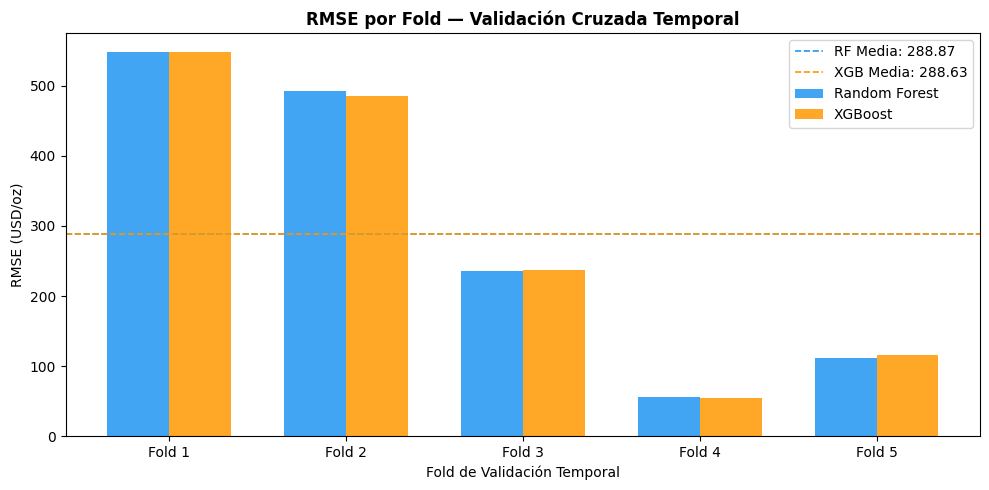

In [18]:
# ============================================================
# Visualización: RMSE por fold
# ============================================================
folds = [f'Fold {i+1}' for i in range(5)]
rmse_rf  = -cv_rf['test_score']
rmse_xgb = -cv_xgb['test_score']

x = np.arange(len(folds))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rmse_rf,  width, label='Random Forest', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, rmse_xgb, width, label='XGBoost',       color='#FF9800', alpha=0.85)

ax.axhline(rmse_rf.mean(),  color='#2196F3', linestyle='--', linewidth=1.2,
           label=f'RF Media: {rmse_rf.mean():.2f}')
ax.axhline(rmse_xgb.mean(), color='#FF9800', linestyle='--', linewidth=1.2,
           label=f'XGB Media: {rmse_xgb.mean():.2f}')

ax.set_xlabel('Fold de Validación Temporal')
ax.set_ylabel('RMSE (USD/oz)')
ax.set_title('RMSE por Fold — Validación Cruzada Temporal', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend()
plt.tight_layout()
plt.show()

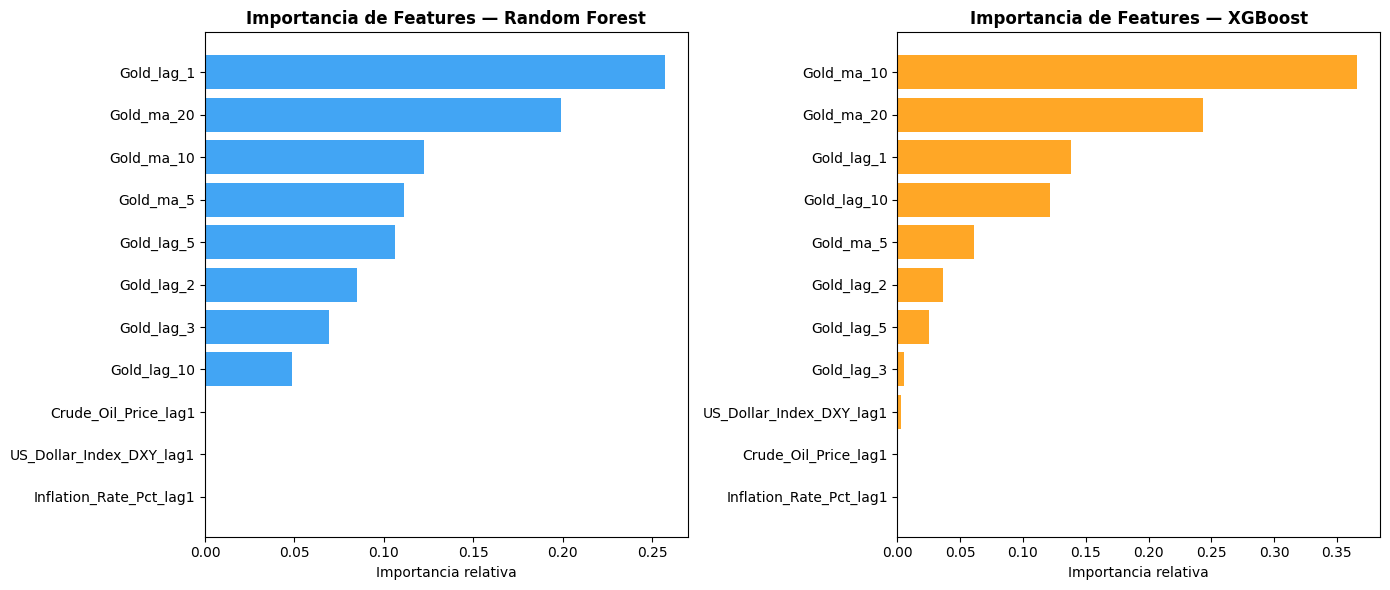

In [19]:
# ============================================================
# Importancia de features del mejor modelo
# ============================================================
# Reentrenar el mejor modelo sobre todos los datos para obtener importancias
best_rf.fit(X, y)
best_xgb.fit(X, y)

importances_rf  = best_rf.named_steps['model'].feature_importances_
importances_xgb = best_xgb.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Feature':       feature_cols,
    'Random Forest': importances_rf,
    'XGBoost':       importances_xgb,
}).sort_values('Random Forest', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, color in zip(axes, ['Random Forest', 'XGBoost'], ['#2196F3', '#FF9800']):
    sub = imp_df.sort_values(col, ascending=True)
    ax.barh(sub['Feature'], sub[col], color=color, alpha=0.85)
    ax.set_title(f'Importancia de Features — {col}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

---

## 9. Conclusiones

A lo largo de este proyecto logramos construir un pipeline completo para la predicción del precio del oro a partir de indicadores macroeconómicos globales, cubriendo desde el análisis exploratorio hasta la comparación de modelos de ensamble.

El EDA confirmó lo que la teoría ya sugería: el oro mantiene una tendencia alcista sostenida con dos aceleraciones claras, durante la pandemia en 2020 y el ciclo geopolítico de 2022–2024, y guarda una relación inversa con el DXY. Esto, combinado con que los precios financieros tienden a "recordar" sus valores anteriores, nos llevó a apostar por la construcción de características temporales como el paso más importante del proyecto. Los rezagos y medias móviles del propio precio del oro terminaron siendo los predictores con mayor peso en ambos modelos, lo cual tiene todo el sentido dado que el precio de ayer es el mejor punto de partida para estimar el de hoy.

En cuanto a los modelos, XGBoost resultó ser el ganador, aunque por un margen muy pequeño: obtuvo un RMSE promedio de 288.63 USD/oz frente a los 288.87 USD/oz de Random Forest. En términos prácticos, esto significa que en promedio ambos modelos se equivocan alrededor de 288 dólares por onza al predecir sobre datos que no han visto antes. La desviación estándar alta en ambos casos no refleja un mal desempeño, sino que es consecuencia natural de trabajar con una serie que cambió mucho de nivel a lo largo del tiempo: los primeros folds tienen precios alrededor de 1,200 USD/oz y los últimos superan los 2,000 USD/oz, por lo que el error absoluto crece en los periodos más recientes simplemente porque los precios son más altos, como se puede apreciar claramente en la gráfica de RMSE por fold.

Finalmente, el uso de Pipeline junto con validación cruzada temporal garantizó que los resultados sean metodológicamente correctos, sin que información futura "se filtrara" hacia el entrenamiento. En conjunto, el proyecto cumplió todos los objetivos planteados y deja una base funcional sobre la que se podría seguir explorando, ya sea incorporando modelos más especializados en series de tiempo o añadiendo variables como tasas de interés o índices de incertidumbre geopolítica.

---

## Referencias

Breiman, L. (1996). Bagging predictors. *Machine Learning, 24*(2), 123–140. https://doi.org/10.1007/BF00058655

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. https://doi.org/10.1145/2939672.2939785

Efron, B. (1979). Bootstrap methods: Another look at the jackknife. *The Annals of Statistics, 7*(1), 1–26. https://doi.org/10.1214/aos/1176344552

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning with applications in Python* (2nd ed.). Springer. https://www.statlearning.com

Salamt, A. (2025). *Gold Price & Global Economic Indicators (2015–2026)* [Dataset]. Kaggle. https://www.kaggle.com/datasets/aminasalamt/gold-price-and-global-economic-indicators15-26